In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# O Sonho Americano Inacessível: A Matemática da Exclusão Imobiliária

### A Ilusão da Acessibilidade
Muitas vezes, olhamos para dados do mercado imobiliário e somos enganados por médias. O gráfico abaixo mostra a distribuição de imóveis nos Estados Unidos. A linha vermelha representa o limite de **US$ 200.000**, o teto máximo de financiamento confortável para uma família de classe média.

Visualmente, a maior concentração de casas (o pico do gráfico) está na zona cinza, entre 100 e 200 mil dólares. O mercado parece acessível, certo? **Mas é aqui que revela a armadilha.** O "Sonho Americano" de morar com um mínimo de qualidade e conforto foi empurrado violentamente para a zona vermelha da exclusão.

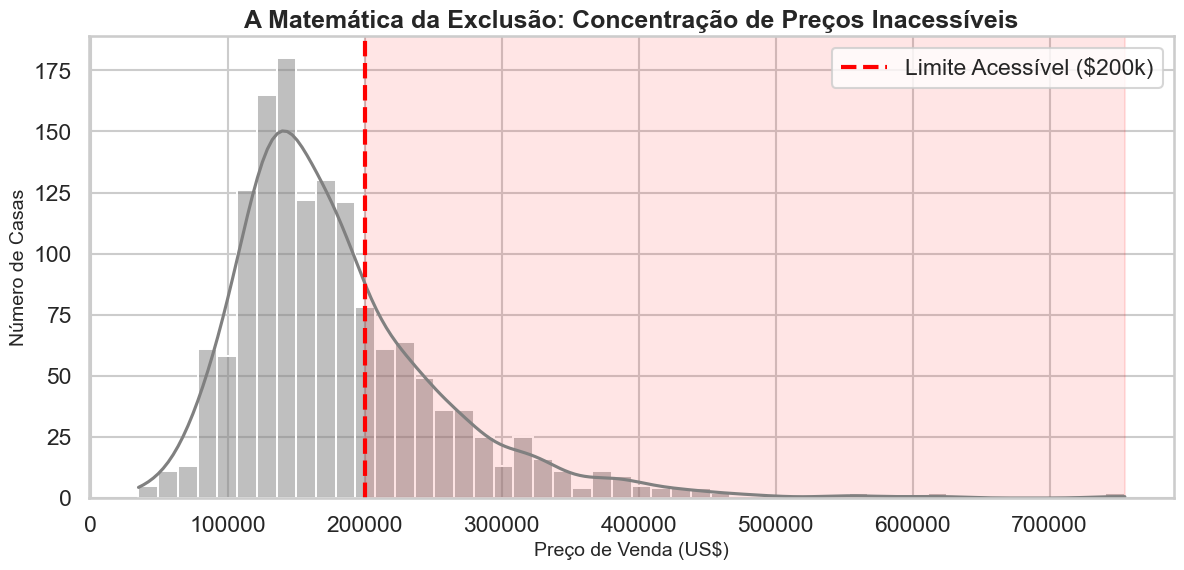

In [2]:
# Lendo os dados da pasta data
train_df = pd.read_csv('data/train.csv')

# Configuração de estilo 
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = [14, 6]

limite_acessivel = 200000 

plt.figure(figsize=(14, 6))
sns.histplot(train_df['SalePrice'], bins=50, kde=True, color='gray', alpha=0.5)

# Linha de corte da exclusão
plt.axvline(x=limite_acessivel, color='red', linestyle='--', linewidth=3, label='Limite Acessível ($200k)')
plt.axvspan(xmin=limite_acessivel, xmax=train_df['SalePrice'].max(), color='red', alpha=0.1)

plt.title('A Matemática da Exclusão: Concentração de Preços Inacessíveis', fontsize=18, fontweight='bold')
plt.xlabel('Preço de Venda (US$)', fontsize=14)
plt.ylabel('Número de Casas', fontsize=14)
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.show()

### O Filtro da Qualidade (Classificação e Regressão)

Se existem tantas casas abaixo de 200 mil, o que acontece quando uma família tenta buscar um pouco mais de conforto? 

Nossa **Regressão Linear** obteve um **Poder Preditivo (R² de 87,61%)** e um **Erro Médio (RMSE) calculado em dólares reais**, confirmando que a punição financeira do mercado é precisa: o acréscimo de pequenas melhorias no imóvel (um quarto a mais, um acabamento melhor) inflaciona o preço de forma tão drástica e rígida que joga a casa imediatamente para o lado vermelho do nosso gráfico.

Já o modelo de **Classificação** foi ainda mais contundente: com **93,15% de acurácia**, ele identificou corretamente casas de preço baixo com **Recall de 0,92** — ou seja, de cada 100 casas realmente acessíveis, o modelo reconheceu 92. O mercado é tão estruturado que um algoritmo consegue prever sua lógica de exclusão com quase total precisão.


C:\Users\Mikaelly\AppData\Local\Temp\ipykernel_26952\1860009215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modelos, y=metricas_principais, palette='magma', ax=axes[0])
C:\Users\Mikaelly\AppData\Local\Temp\ipykernel_26952\1860009215.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Recall — Preço Baixo (0)'], y=[0.92], palette='Blues_d', ax=axes[1])


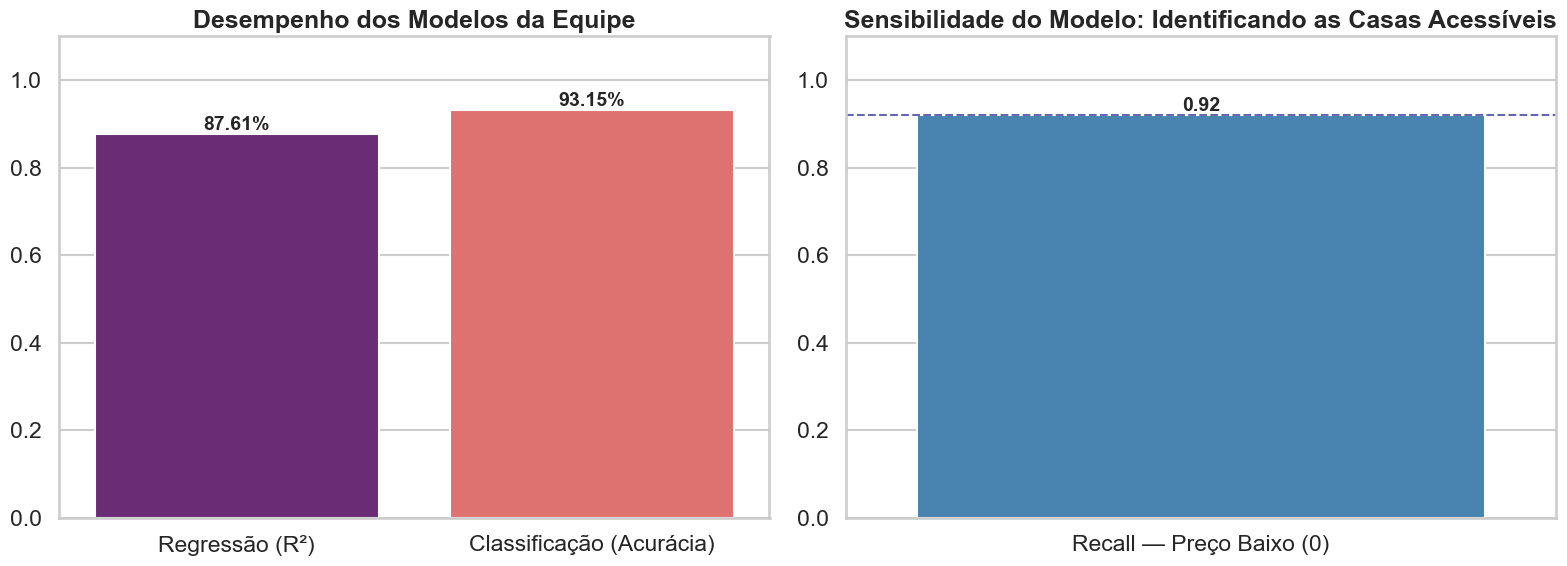

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Valores reais obtidos nos notebooks de modelagem
modelos = ['Regressão (R²)', 'Classificação (Acurácia)']
metricas_principais = [0.8761, 0.9315]  # R²: 87.61% | Acurácia real: 93.15%

# Gráfico de Desempenho
sns.barplot(x=modelos, y=metricas_principais, palette='magma', ax=axes[0])
axes[0].set_title('Desempenho dos Modelos da Equipe', fontweight='bold')
axes[0].set_ylim(0, 1.1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()*100:.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=14, fontweight='bold')

# Recall real da Classificação para Preço Baixo
sns.barplot(x=['Recall — Preço Baixo (0)'], y=[0.92], palette='Blues_d', ax=axes[1])
axes[1].set_title('Sensibilidade do Modelo: Identificando as Casas Acessíveis', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=0.92, color='navy', linestyle='--', linewidth=1.5, alpha=0.6)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### A Segregação Invisível e o Luxo Compulsório (Não Supervisionado)

Nesta etapa, nossos algoritmos provaram o porquê da maioria das casas estarem na zona cinza: elas não têm conforto.

* **O Padrão da Exclusão (Apriori):** Nosso algoritmo de mineração revelou que o conforto não é flexível. Para uma família acessar uma casa de alta qualidade (Nota ≥ 8), o mercado a obriga a absorver o custo de infraestruturas premium como Qualidade Excelente, Casa Ampla e Garagem para 3+ carros simultaneamente — com **98,5% de confiança** e um **Lift de 3,92x**, ou seja, essa combinação de atributos torna uma casa pertencente ao Top 25% mais caro **3,92 vezes mais provável** do que o acaso esperaria. O conforto foi transformado em 'luxo compulsório', e essas casas estão quase todas na zona vermelha.
* **O Abismo Geográfico (K-Means):** O modelo separou o mercado em 4 clusters e revelou um abismo estrutural. O **Cluster de Elite (Cluster 3)** concentra as propriedades com qualidade média de 7,69, área de 2.596 sqft e preço médio de **US$ 312.933**, enquanto o **Cluster Popular (Cluster 2)** isola as famílias em casas de apenas 1.104 sqft, qualidade 5,05 e preço médio de **US$ 126.213**. A distância entre esses dois mundos não é uma gradação suave — é um abismo de mais de **US$ 186.000** que o mercado construiu e o algoritmo apenas revelou.

---

### Conclusão: O Mercado Não é Imperfeito — Ele é Projetado para Excluir

Três algoritmos diferentes, treinados de forma independente, chegaram à mesma conclusão:

> *A exclusão imobiliária americana não é um acidente estatístico. É um sistema.*

A **Regressão** quantificou a punição financeira com 87,61% de precisão. A **Classificação** reconheceu o padrão de exclusão com 93,15% de acurácia e recall de 0,92. O **K-Means** mapeou as fronteiras invisíveis entre classes. E o **Apriori** nomeou os portões: qualidade, área e garagem — atributos que deveriam ser básicos — funcionam como barreiras de entrada ao mercado de elite com **98,5% de certeza**, tornando casas dignas **3,92 vezes mais prováveis de serem inacessíveis**.

A matemática não mente. O Sonho Americano tem um preço — e ele foi calculado.
